In [42]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [1]:
#That line of code is the standard way to load the MNIST dataset directly from TensorFlow/Keras.
import tensorflow as tf
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [2]:
x_train.shape[0]

60000

In [3]:
y_train.shape

(60000,)

In [4]:
x_test.shape

(10000, 28, 28)

In [5]:
y_test.shape

(10000,)

In [6]:
#Adding gray scale image channel as 1, if its RGB then it is 3
#(batch_size, height, width, channels)
x_train = x_train.reshape(x_train.shape[0],28,28,1)
x_test = x_test.reshape(x_test.shape[0],28,28,1)
input_shape = (28, 28, 1)

In [7]:
type(input_shape)

tuple

In [8]:
x_train.shape

(60000, 28, 28, 1)

In [9]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [10]:
#Pixel values in MNIST/Fashion‑MNIST are integers from 0 to 255 (grayscale intensity).
#Dividing by 255 scales them into the range [0, 1].
#Example:
#Black pixel (0) → 0.0
#White pixel (255) → 1.0
#Mid‑gray (128) → ~0.5
x_train /= 255
x_test /=255

In [11]:
#Neural networks don’t understand categories directly.  They need numeric vectors to represent classes.
from keras.utils import to_categorical
from tensorflow.keras.utils import to_categorical
y_train_digit = to_categorical(y_train, num_classes=10)
y_test_digit = to_categorical(y_test, num_classes=10)

In [18]:
print(y_train_digit[100])
print(y_train.shape)
print(y_train[100])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
(60000,)
5


In [19]:
#Conv2D + Pooling → Extract local features (edges, shapes).
#Flatten + Dense → Combine features into abstract representations.
#Dropout → Regularize and prevent overfitting.
#Softmax output → Predict class probabilities.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
model = Sequential()
model.add(Conv2D(28, kernel_size=(3,3), input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation=tf.nn.relu))
model.add(Dropout(0.2))
model.add(Dense(10,activation=tf.nn.softmax))

C:\Users\DELL\anaconda3\envs\ml_ai\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x=x_train, y=y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.9368 - loss: 0.2090
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9747 - loss: 0.0832
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9814 - loss: 0.0591
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9861 - loss: 0.0439
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9879 - loss: 0.0369
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9902 - loss: 0.0292
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 24ms/step - accuracy: 0.9915 - loss: 0.0252
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 78s 21ms/step - accuracy: 0.9924 - loss: 0.0219
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9932 - loss: 0.0203
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.9940 - loss: 0.0175


In [24]:
test_loss_digit, test_acc_digit = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9858 - loss: 0.0626


In [25]:
print('Digit MNIST test accuracy:', round(test_acc_digit,4))

Digit MNIST test accuracy: 0.9858


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
2


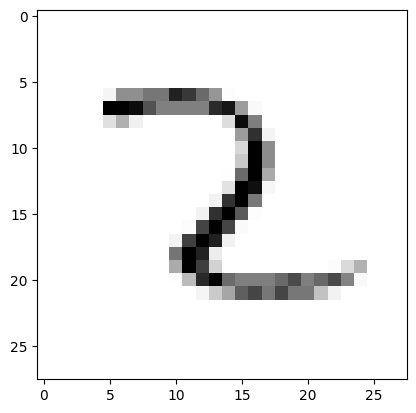

In [26]:
import matplotlib.pyplot as plt
image_index = 2500
plt.imshow(x_test[image_index].reshape(28,28), cmap='Greys')
predict = x_test[image_index].reshape(28,28)
pred = model.predict(x_test[image_index].reshape(1,28,28,1))
print(pred.argmax())


In [27]:
y_predict = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [28]:
print(y_predict.shape)

(10000, 10)


In [31]:
#The process of convering vector array into normal 1 D array
#[0.01, 0.05, 0.02, 0.80, 0.03, 0.04, 0.02, 0.01, 0.01, 0.01] --> [0,0,0,1,0,0,0,0,0,0] which is nothing but 3
y_predicts = np.argmax(y_predict, axis=1) #Convert the matrix array inot 0 and 1s and then Finds the index of the maximum value along each row.

In [31]:
y_test_digit[8]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [36]:
y_predicts[8]

np.int64(5)

In [37]:
y_test_digit_eval = np.argmax(y_test_digit, axis=1)

In [38]:
y_test_digit_eval[8]

np.int64(5)

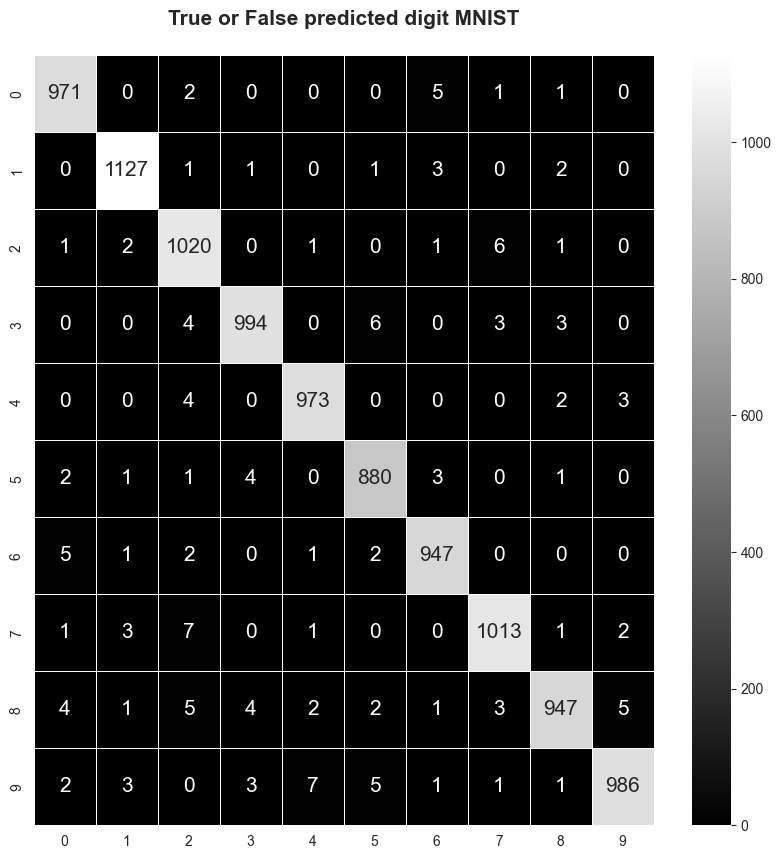

In [43]:
#Confusion Matrix
#Diagonal cells (top‑left to bottom‑right) = correct predictions
#Off‑diagonal cells = misclassifications (e.g., predicting “3” when the true digit was “5”).
#Darker cells = higher counts.
#972 → the model correctly predicted 972 images of digit “0” as “0”.
#1110 → the model correctly predicted 1110 images of digit “1” as “1”.
#983 → the model correctly predicted 983 images of digit “2” as “2”.
import matplotlib.pyplot as plt
con_mat = confusion_matrix(y_test_digit_eval, y_predicts)
sns.set_style("darkgrid")
plt.figure(figsize=(10,10))
sns.heatmap(con_mat, annot=True,annot_kws={'size':15},linewidths=0.5,fmt='d',cmap='gray')
plt.title('True or False predicted digit MNIST\n',fontweight='bold',fontsize=15)
plt.show()

In [44]:
print(type(y_test))
print(type(y_test_digit))
print(type(y_test_digit_eval))
#from sklearn.metrics import classification_report
#print(classification_report(y_test_digit_eval,y_predicts))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [45]:
print(y_test[3])
print(y_test_digit[3])
print(y_test_digit_eval[3])

0
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
0


In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test_digit_eval,y_predicts))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.98      1032
           3       0.99      0.98      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.98       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.97      0.98       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [65]:
#print(x_test[[2]])
y_predict_single = model.predict(x_test[[3]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


In [61]:
print(y_predict_single)

[[3.8467474e-10 9.9999833e-01 2.0016499e-08 1.3972519e-11 6.3941258e-07
  7.4889828e-09 1.5721080e-08 9.3867789e-07 9.5902401e-08 7.0272984e-12]]


In [66]:
y_predicts_single_value = np.argmax(y_predict_single, axis=1)
print(y_predicts_single_value[0])

0


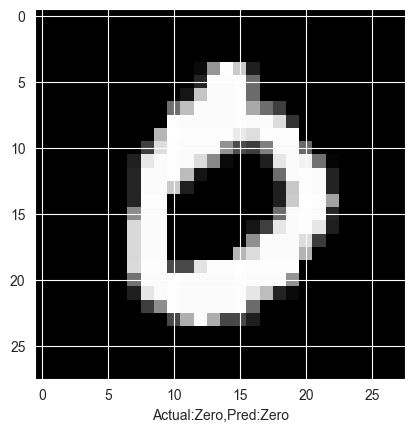

In [67]:
#Names of numbers in the dataset in order
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

#Visualizing the digits
#plt.figure(figsize=(10,10))
plt.imshow(x_test[3].reshape(28,28), cmap='gray')
plt.xlabel("Actual:{},Pred:{}".format(col_names[np.argmax(y_test_digit[3])],col_names[y_predicts_single_value[0]]))
plt.show()